Загрузка датасета

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("panaaaaa/english-premier-league-and-championship-full-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\panaaaaa\english-premier-league-and-championship-full-dataset\versions\1


Подготовка данных

In [45]:
import pandas as pd 

df = pd.read_csv("England CSV.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12153 entries, 0 to 12152
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           12153 non-null  object 
 1   Season         12153 non-null  object 
 2   HomeTeam       12153 non-null  object 
 3   AwayTeam       12153 non-null  object 
 4   FTH Goals      12153 non-null  int64  
 5   FTA Goals      12153 non-null  int64  
 6   FT Result      12153 non-null  object 
 7   HTH Goals      11229 non-null  float64
 8   HTA Goals      11229 non-null  float64
 9   HT Result      11229 non-null  object 
 10  Referee        9329 non-null   object 
 11  H Shots        9329 non-null   float64
 12  A Shots        9329 non-null   float64
 13  H SOT          9329 non-null   float64
 14  A SOT          9329 non-null   float64
 15  H Fouls        9329 non-null   float64
 16  A Fouls        9329 non-null   float64
 17  H Corners      9329 non-null   float64
 18  A Corn

In [46]:
df


,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12148,14/08/1993,1993/94,Southampton,Everton,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19930814,Premier League
12149,14/08/1993,1993/94,Sheffield United,Swindon,3,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19930814,Premier League
12150,14/08/1993,1993/94,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19930814,Premier League
12151,14/08/1993,1993/94,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19930814,Premier League


In [47]:
df = df[df["Season"].between('2014/15','2024/25')]

Статистика

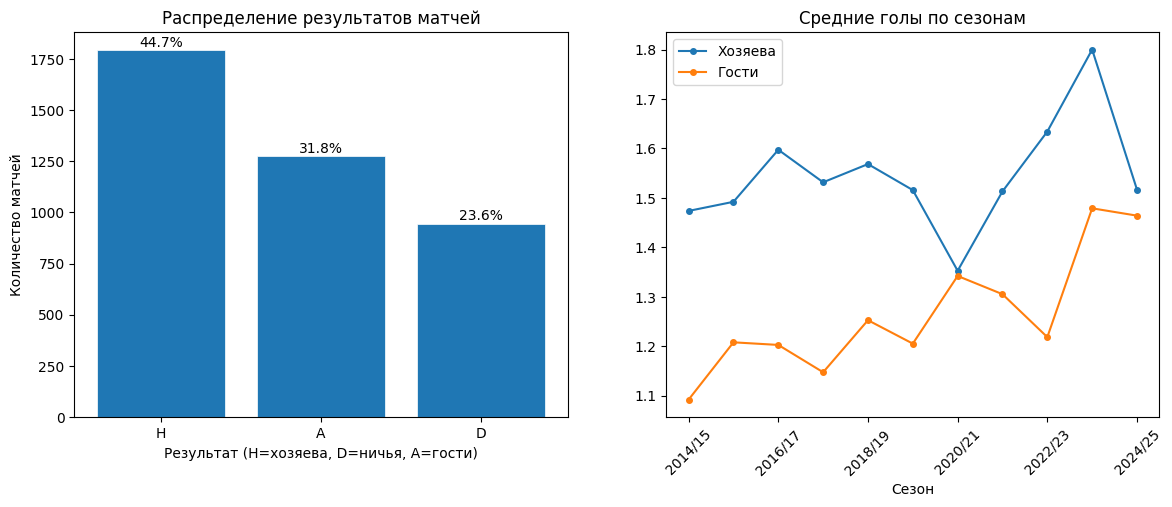

In [48]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

result_counts = df['FT Result'].value_counts()
axes[0].bar(result_counts.index, result_counts.values, edgecolor='white', linewidth=0.5)
axes[0].set_title('Распределение результатов матчей')
axes[0].set_xlabel('Результат (H=хозяева, D=ничья, A=гости)')
axes[0].set_ylabel('Количество матчей')
for i, (lbl, v) in enumerate(result_counts.items()):
    axes[0].text(i, v + 20, f'{v/len(df)*100:.1f}%', ha='center', fontsize=10)

season_goals = df.groupby('Season')[['FTH Goals', 'FTA Goals']].mean()
season_goals.plot(ax=axes[1], marker='o', markersize=4)
axes[1].set_title('Средние голы по сезонам')
axes[1].set_xlabel('Сезон')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Хозяева', 'Гости'])



Изменение таблицы

In [49]:
home = df.copy()
home["Venue"]    = "Home"
home["Team"]     = df["HomeTeam"]
home["Opponent"] = df["AwayTeam"]
home["GF"]       = df["FTH Goals"]   # голов забили
home["GA"]       = df["FTA Goals"]   # голов пропустили
home["Result"]   = df["FT Result"].map({"H": "Win", "D": "Draw", "A": "Loss"})
home["SH"]       = df["H Shots"]
home["SOT"]      = df["H SOT"]
home["Corners"]  = df["H Corners"]
home["Fouls"]    = df["H Fouls"]
home["Yellow"]   = df["H Yellow"]
home["Red"]      = df["H Red"]


away = df.copy()
away["Venue"]    = "Away"
away["Team"]     = df["AwayTeam"]
away["Opponent"] = df["HomeTeam"]
away["GF"]       = df["FTA Goals"]
away["GA"]       = df["FTH Goals"]
away["Result"]   = df["FT Result"].map({"H": "Loss", "D": "Draw", "A": "Win"})
away["SH"]       = df["A Shots"]
away["SOT"]      = df["A SOT"]
away["Corners"]  = df["A Corners"]
away["Fouls"]    = df["A Fouls"]
away["Yellow"]   = df["A Yellow"]
away["Red"]      = df["A Red"]


matches_01 = pd.concat([home, away], ignore_index=True)

matches = matches_01[[
    "Date", "Season", "Team", "Venue", "Opponent",
    "GF", "GA", "Result",
    "SH", "SOT", "Corners", "Fouls", "Yellow", "Red"
]].copy()

matches


,Date,Season,Team,Venue,Opponent,GF,GA,Result,SH,SOT,Corners,Fouls,Yellow,Red
0,16/01/2025,2024/25,Ipswich Town,Home,Brighton & Hove Albion,0,2,Loss,5.0,3.0,1.0,13.0,2.0,0.0
1,16/01/2025,2024/25,Man United,Home,Southampton,3,1,Win,23.0,9.0,4.0,7.0,1.0,0.0
2,15/01/2025,2024/25,Everton,Home,Aston Villa,0,1,Loss,10.0,3.0,8.0,17.0,2.0,0.0
3,15/01/2025,2024/25,Leicester,Home,Crystal Palace,0,2,Loss,21.0,4.0,4.0,7.0,0.0,0.0
4,15/01/2025,2024/25,Newcastle,Home,Wolves,3,0,Win,17.0,5.0,4.0,10.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8013,16/08/2014,2014/15,Crystal Palace,Away,Arsenal,1,2,Loss,4.0,2.0,3.0,19.0,2.0,1.0
8014,16/08/2014,2014/15,Everton,Away,Leicester,2,2,Draw,13.0,3.0,6.0,10.0,1.0,0.0
8015,16/08/2014,2014/15,Hull,Away,QPR,1,0,Win,11.0,4.0,9.0,10.0,2.0,0.0
8016,16/08/2014,2014/15,Swansea,Away,Man United,2,1,Win,5.0,4.0,0.0,20.0,4.0,0.0


In [50]:
matches['Date'] = pd.to_datetime(matches['Date'], dayfirst=True)

In [51]:
matches.dtypes

Date        datetime64[ns]
Season              object
Team                object
Venue               object
Opponent            object
GF                   int64
GA                   int64
Result              object
SH                 float64
SOT                float64
Corners            float64
Fouls              float64
Yellow             float64
Red                float64
dtype: object

целевая переменная

In [52]:
matches['venue_code'] = matches['Venue'].astype('category').cat.codes
matches['opp_code'] = matches['Opponent'].astype('category').cat.codes
# matches['day_code'] = matches['Date'].dt.dayofweek
matches['target'] = (matches['Result'] == 'Win').astype('int')



In [53]:
matches.isna().sum()

Date          0
Season        0
Team          0
Venue         0
Opponent      0
GF            0
GA            0
Result        0
SH            0
SOT           0
Corners       0
Fouls         0
Yellow        0
Red           0
venue_code    0
opp_code      0
target        0
dtype: int64

In [54]:
matches = matches.sort_values('Date')


Training (Random Forest)

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
rf = RandomForestClassifier(n_estimators=50, min_samples_split=10, random_state=1)

train = matches[matches['Date'] < '2022-01-01']
test = matches[matches['Date'] >= '2022-01-01']
predictors = ['venue_code', 'opp_code']
rf.fit(train[predictors], train['target'])




,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
preds = rf.predict(test[predictors])


In [58]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(test['target'], preds)
acc

0.5853344768439108

In [59]:
combined = pd.DataFrame(dict(actual = test['target'], predicton = preds))
pd.crosstab(index=combined['actual'], columns=combined['predicton'])

predicton,0,1
actual,,
0,1146,287
1,680,219


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [61]:
precision_score(test['target'], preds)

0.43280632411067194

In [62]:
print("Recall:", recall_score(test['target'], preds))
print("F1:", f1_score(test['target'], preds))
print("Confusion Matrix:")
print(confusion_matrix(test['target'], preds))


Recall: 0.2436040044493882
F1: 0.3117437722419929
Confusion Matrix:
[[1146  287]
 [ 680  219]]


Training (Logistic Regression)

In [63]:
from sklearn.linear_model import LogisticRegression


In [64]:
lr = LogisticRegression(max_iter=1000)
lr.fit(train[predictors], train['target'])
lr_preds = lr.predict(test[predictors])


In [65]:
print("Accuracy:", accuracy_score(test['target'], lr_preds))
print("Precision:", precision_score(test['target'], lr_preds))
print("Recall:", recall_score(test['target'], lr_preds))
print("F1:", f1_score(test['target'], lr_preds))

print("Confusion Matrix:")
print(confusion_matrix(test['target'], lr_preds))

Accuracy: 0.6144939965694682
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion Matrix:
[[1433    0]
 [ 899    0]]


c:\Users\user\Desktop\self-study\python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Сравнение моделей

In [66]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(test['target'], preds),
        accuracy_score(test['target'], lr_preds)
    ],
    "Precision": [
        precision_score(test['target'], preds),
        precision_score(test['target'], lr_preds)
    ],
    "Recall": [
        recall_score(test['target'], preds),
        recall_score(test['target'], lr_preds)
    ],
    "F1": [
        f1_score(test['target'], preds),
        f1_score(test['target'], lr_preds)
    ]
})

results

c:\Users\user\Desktop\self-study\python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.585334,0.432806,0.243604,0.311744
1,Logistic Regression,0.614494,0.000000,0.000000,0.000000


improving accur

In [67]:
grouped_matches = matches.groupby('Team')

In [68]:
group = grouped_matches.get_group('Chelsea')
group

,Date,Season,Team,Venue,Opponent,GF,GA,Result,SH,SOT,Corners,Fouls,Yellow,Red,venue_code,opp_code,target
8008,2014-08-18,2014/15,Chelsea,Away,Burnley,3,1,Win,11.0,3.0,3.0,7.0,1.0,0.0,0,6,1
3996,2014-08-23,2014/15,Chelsea,Home,Leicester,2,0,Win,27.0,10.0,8.0,11.0,0.0,0.0,1,17,1
7997,2014-08-30,2014/15,Chelsea,Away,Everton,6,3,Win,12.0,8.0,2.0,16.0,3.0,0.0,0,10,1
3972,2014-09-13,2014/15,Chelsea,Home,Swansea,4,2,Win,29.0,9.0,7.0,12.0,0.0,0.0,1,31,1
7968,2014-09-21,2014/15,Chelsea,Away,Man City,1,1,Draw,6.0,2.0,2.0,12.0,4.0,0.0,0,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4049,2024-12-22,2024/25,Chelsea,Away,Everton,0,0,Draw,12.0,5.0,5.0,12.0,1.0,0.0,0,10,0
34,2024-12-26,2024/25,Chelsea,Home,Fulham,1,2,Loss,12.0,8.0,3.0,13.0,1.0,0.0,1,11,0
4031,2024-12-30,2024/25,Chelsea,Away,Ipswich,0,2,Loss,20.0,5.0,7.0,5.0,4.0,0.0,0,14,0
4025,2025-01-04,2024/25,Chelsea,Away,Crystal Palace,1,1,Draw,15.0,1.0,6.0,12.0,2.0,0.0,0,9,0


In [69]:
def rolling_averages(group, cols, new_cols):
    group = group.sort_values('Date')
    rolling_stats = group[cols].rolling(3, closed = 'left').mean()
    group[new_cols] = rolling_stats
    group = group.dropna(subset=new_cols)
    return group

In [70]:
cols = ['GF', 'GA', 'SH', 'SOT', 'Fouls', 'Yellow', 'Red']
new_cols = [f'{c}_rolling' for c in cols]
new_cols

['GF_rolling',
 'GA_rolling',
 'SH_rolling',
 'SOT_rolling',
 'Fouls_rolling',
 'Yellow_rolling',
 'Red_rolling']

In [71]:
rolling_averages(group, cols, new_cols)

,Date,Season,Team,Venue,Opponent,GF,GA,Result,SH,SOT,...,venue_code,opp_code,target,GF_rolling,GA_rolling,SH_rolling,SOT_rolling,Fouls_rolling,Yellow_rolling,Red_rolling
3972,2014-09-13,2014/15,Chelsea,Home,Swansea,4,2,Win,29.0,9.0,...,1,31,1,3.666667,1.333333,16.666667,7.000000,11.333333,1.333333,0.000000
7968,2014-09-21,2014/15,Chelsea,Away,Man City,1,1,Draw,6.0,2.0,...,0,20,0,4.000000,1.666667,22.666667,9.000000,13.000000,1.000000,0.000000
3957,2014-09-27,2014/15,Chelsea,Home,Aston Villa,3,0,Win,17.0,8.0,...,1,1,1,3.666667,2.000000,15.666667,6.333333,13.333333,2.333333,0.000000
3940,2014-10-05,2014/15,Chelsea,Home,Arsenal,2,0,Win,5.0,3.0,...,1,0,1,2.666667,1.000000,17.333333,6.333333,11.666667,2.000000,0.000000
7947,2014-10-18,2014/15,Chelsea,Away,Crystal Palace,2,1,Win,14.0,5.0,...,0,9,1,2.000000,0.333333,9.333333,4.333333,12.333333,3.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4049,2024-12-22,2024/25,Chelsea,Away,Everton,0,0,Draw,12.0,5.0,...,0,10,0,3.666667,1.666667,23.000000,9.666667,12.000000,0.666667,0.333333
34,2024-12-26,2024/25,Chelsea,Home,Fulham,1,2,Loss,12.0,8.0,...,1,11,0,2.000000,1.333333,18.333333,7.000000,11.333333,1.000000,0.333333
4031,2024-12-30,2024/25,Chelsea,Away,Ipswich,0,2,Loss,20.0,5.0,...,0,14,0,1.000000,1.000000,16.666667,7.000000,12.000000,0.666667,0.333333
4025,2025-01-04,2024/25,Chelsea,Away,Crystal Palace,1,1,Draw,15.0,1.0,...,0,9,0,0.333333,1.333333,14.666667,6.000000,10.000000,2.000000,0.000000


In [72]:
matches_rolling = matches.groupby('Team').apply(lambda x: rolling_averages(x, cols, new_cols))
matches_rolling = matches_rolling.droplevel('Team')
matches_rolling.index = range(matches_rolling.shape[0])
matches_rolling

C:\Users\user\AppData\Local\Temp\ipykernel_20148\2835256514.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  matches_rolling = matches.groupby('Team').apply(lambda x: rolling_averages(x, cols, new_cols))


,Date,Season,Team,Venue,Opponent,GF,GA,Result,SH,SOT,...,venue_code,opp_code,target,GF_rolling,GA_rolling,SH_rolling,SOT_rolling,Fouls_rolling,Yellow_rolling,Red_rolling
0,2014-09-13,2014/15,Arsenal,Home,Man City,2,2,Draw,15.0,6.0,...,1,20,0,1.666667,1.333333,17.000000,5.000000,12.333333,2.333333,0.000000
1,2014-09-20,2014/15,Arsenal,Away,Aston Villa,3,0,Win,9.0,3.0,...,0,1,1,1.666667,1.666667,17.333333,5.000000,11.666667,2.666667,0.000000
2,2014-09-27,2014/15,Arsenal,Home,Tottenham,1,1,Draw,16.0,6.0,...,1,32,0,2.000000,1.000000,16.000000,5.000000,8.666667,2.333333,0.000000
3,2014-10-05,2014/15,Arsenal,Away,Chelsea,0,2,Loss,10.0,0.0,...,0,8,0,2.000000,1.000000,13.333333,5.000000,9.000000,3.000000,0.000000
4,2014-10-18,2014/15,Arsenal,Home,Hull,2,2,Draw,25.0,9.0,...,1,13,0,1.333333,1.000000,11.666667,3.000000,8.666667,3.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7904,2024-12-22,2024/25,Wolves,Away,Leicester,3,0,Win,8.0,4.0,...,0,17,1,0.666667,2.666667,13.666667,4.333333,12.666667,1.333333,0.333333
7905,2024-12-26,2024/25,Wolves,Home,Man United,2,0,Win,7.0,4.0,...,1,21,1,1.666667,1.333333,14.333333,5.000000,15.333333,1.333333,0.333333
7906,2024-12-29,2024/25,Wolves,Away,Tottenham,2,2,Draw,11.0,3.0,...,0,32,0,2.000000,0.666667,10.333333,4.666667,13.666667,0.666667,0.333333
7907,2025-01-06,2024/25,Wolves,Home,Nott'm Forest,0,3,Loss,13.0,6.0,...,1,25,0,2.333333,0.666667,8.666667,3.666667,12.666667,1.333333,0.000000


Retraing model

In [73]:
def make_predictions(data, predictors, model):
    data = data.sort_values('Date')
    train = data[data['Date'] < '2022-01-01']
    test = data[data['Date'] >= '2022-01-01']
    model.fit(train[predictors], train['target'])
    preds = model.predict(test[predictors])

    combined = pd.DataFrame(dict(actual = test['target'], predicton = preds), index = test.index)
    precision = precision_score(test['target'], preds)
    accuracy = accuracy_score(test['target'], preds)
    precision = precision_score(test['target'], preds)
    recall = recall_score(test['target'], preds)
    f1 = f1_score(test['target'], preds)

    return combined, accuracy, precision, recall, f1


In [74]:
rf = RandomForestClassifier(n_estimators=50, min_samples_split=10, random_state=1)

combined_rf, accuracy_rf, precision_rf, recall_rf, f1_rf = make_predictions(
    matches_rolling,
    predictors + new_cols,
    rf
)

print("Random Forest with rolling averages")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1:", f1_rf)

Random Forest with rolling averages
Accuracy: 0.6338939197930142
Precision: 0.5348837209302325
Recall: 0.41025641025641024
F1: 0.4643533123028391


In [75]:
lr = LogisticRegression(max_iter=1000)

combined_lr, accuracy_lr, precision_lr, recall_lr, f1_lr = make_predictions(
    matches_rolling,
    predictors + new_cols,
    lr
)

print("Logistic Regression with rolling averages")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1:", f1_lr)

Logistic Regression with rolling averages
Accuracy: 0.6446744286330315
Precision: 0.5749486652977412
Recall: 0.31215161649944256
F1: 0.4046242774566474


In [76]:
results_rolling = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [accuracy_rf, accuracy_lr],
    "Precision": [precision_rf, precision_lr],
    "Recall": [recall_rf, recall_lr],
    "F1": [f1_rf, f1_lr]
})

results_rolling

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.633894,0.534884,0.410256,0.464353
1,Logistic Regression,0.644674,0.574949,0.312152,0.404624


Merging

In [77]:
class MissingDict(dict):
    __missing__ = lambda self, key: key
    
map_values = {
    'Brighton & Hove Albion' : 'Brighton',
    'Ipswich Town' : 'Ipswich'
}
mapping = MissingDict(**map_values)

In [87]:
mapping['Brighton & Hove Albion']

'Brighton'

In [78]:
combined_rf = combined_rf.merge(
    matches_rolling[['Date', 'Team', 'Opponent', 'Result']],
    left_index=True,
    right_index=True
)

combined_rf

,actual,predicton,Date,Team,Opponent,Result
2396,0,0,2022-01-01,Crystal Palace,West Ham,Loss
282,0,1,2022-01-01,Arsenal,Man City,Loss
4427,1,1,2022-01-01,Man City,Arsenal,Win
7057,0,0,2022-01-01,Watford,Tottenham,Loss
7547,1,0,2022-01-01,West Ham,Crystal Palace,Win
...,...,...,...,...,...,...
2908,0,0,2025-01-15,Everton,Aston Villa,Loss
3711,0,0,2025-01-15,Leicester,Crystal Palace,Loss
7908,0,0,2025-01-15,Wolves,Newcastle,Loss
6045,0,0,2025-01-16,Southampton,Man United,Loss


In [79]:
combined_rf.columns

Index(['actual', 'predicton', 'Date', 'Team', 'Opponent', 'Result'], dtype='object')

In [80]:
combined_rf["new_team"] = combined_rf["Team"].map(mapping)

In [81]:
merged = combined_rf.merge(
    combined_rf,
    left_on=["Date", "new_team"],
    right_on=["Date", "Opponent"]
)

merged.head()

,actual_x,predicton_x,Date,Team_x,Opponent_x,Result_x,new_team_x,actual_y,predicton_y,Team_y,Opponent_y,Result_y,new_team_y
0,0,0,2022-01-01,Crystal Palace,West Ham,Loss,Crystal Palace,1,0,West Ham,Crystal Palace,Win,West Ham
1,0,1,2022-01-01,Arsenal,Man City,Loss,Arsenal,1,1,Man City,Arsenal,Win,Man City
2,1,1,2022-01-01,Man City,Arsenal,Win,Man City,0,1,Arsenal,Man City,Loss,Arsenal
3,0,0,2022-01-01,Watford,Tottenham,Loss,Watford,1,1,Tottenham,Watford,Win,Tottenham
4,1,0,2022-01-01,West Ham,Crystal Palace,Win,West Ham,0,0,Crystal Palace,West Ham,Loss,Crystal Palace


In [82]:
merged[
    (merged["predicton_x"] == 1) & 
    (merged["predicton_y"] == 0)
]["actual_x"].value_counts()

actual_x
1    327
0    250
Name: count, dtype: int64

сохранение 

In [83]:
matches_rolling
predictors
new_cols
rf

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

base_predictors = ["venue_code", "opp_code"]

final_predictors = base_predictors + new_cols

matches_rolling = matches_rolling.sort_values("Date")

train = matches_rolling[matches_rolling["Date"] < "2022-01-01"]
test = matches_rolling[matches_rolling["Date"] >= "2022-01-01"]

X_train = train[final_predictors]
y_train = train["target"]

X_test = test[final_predictors]
y_test = test["target"]

final_model = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=10,
    random_state=1
)

final_model.fit(X_train, y_train)

preds = final_model.predict(X_test)

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

model_data = {
    "model": final_model,
    "matches_rolling": matches_rolling,
    "predictors": final_predictors,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

joblib.dump(model_data, "football_model.pkl")

print("Model saved successfully")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Model saved successfully
Accuracy: 0.6338939197930142
Precision: 0.5348837209302325
Recall: 0.41025641025641024
F1: 0.4643533123028391
